# Exploratory Data Analysis on Cars24 Used-Car Data

**Goal:** understand what drives the selling price of used cars and prepare the data for modelling.

**Dataset:** 13,986 used-car listings, 11 raw columns (name, year, seller type, km driven, fuel type, transmission, mileage, engine, max power, seats, selling price). Price is in lakhs (INR).

**Steps:** data checks and outlier handling, distributions, categorical analysis, feature engineering (age, make/model, encoding), scaling, correlation analysis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving train-cars24-car-price.csv to train-cars24-car-price.csv


In [3]:
df = pd.read_csv("train-cars24-car-price.csv")
df.head()

,full_name,selling_price,year,seller_type,km_driven,fuel_type,transmission_type,mileage,engine,max_power,seats
0,Maruti SX4 Zxi BSIII,2.85,2007.0,Individual,110000,Petrol,Manual,15.00,1586.0,104.68,5.0
1,Hyundai i20 Sportz 1.4 CRDi,4.70,2012.0,Dealer,70000,Diesel,Manual,21.90,1396.0,88.76,5.0
2,Maruti Swift VDI BSIV,5.25,2015.0,Individual,70000,Diesel,Manual,25.20,1248.0,74.00,5.0
3,Honda City 1.3 EXI,1.25,2005.0,Individual,90000,Petrol,Manual,13.00,1343.0,90.00,5.0
4,Volkswagen Polo 1.2 MPI Comfortline,4.65,2015.0,Dealer,41000,Petrol,Manual,16.47,1198.0,74.00,5.0


In [4]:
df.shape

(13986, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13986 entries, 0 to 13985
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   full_name          13986 non-null  object 
 1   selling_price      13986 non-null  float64
 2   year               13986 non-null  float64
 3   seller_type        13986 non-null  object 
 4   km_driven          13986 non-null  int64  
 5   fuel_type          13986 non-null  object 
 6   transmission_type  13986 non-null  object 
 7   mileage            13986 non-null  float64
 8   engine             13986 non-null  float64
 9   max_power          13986 non-null  float64
 10  seats              13986 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.2+ MB


In [6]:
display(df.describe())

,selling_price,year,km_driven,mileage,engine,max_power,seats
count,13986.000000,13986.000000,1.398600e+04,13986.000000,13986.000000,13986.000000,13986.000000
mean,7.377749,2014.516088,5.797629e+04,19.356221,1473.574905,97.685631,5.313242
std,9.368596,3.256795,5.378180e+04,4.638576,518.289204,45.067944,0.831653
min,0.325000,1991.000000,1.000000e+02,0.000000,0.000000,5.000000,2.000000
25%,3.400000,2013.000000,3.100000e+04,16.840000,1197.000000,73.900000,5.000000
50%,5.100000,2015.000000,5.120000e+04,19.160000,1248.000000,86.700000,5.000000
75%,7.800000,2017.000000,7.397800e+04,22.320000,1582.000000,112.000000,5.000000
max,395.000000,2021.000000,3.800000e+06,120.000000,6752.000000,626.000000,14.000000




Lets check the distributions of these features one by one

<Axes: >

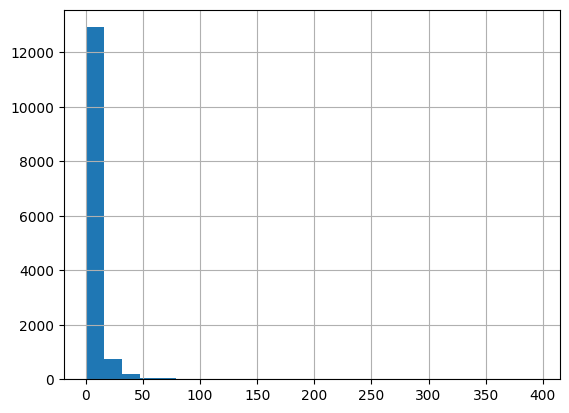

In [7]:
df['selling_price'].hist(bins=25)

Lets check the percntage of outliers. We are manually taking a call that price over a 100 lakhs is an outlier by looking at the above plot

In [8]:
(df.loc[df.selling_price > 100].shape[0] / df.shape[0]) * 100

0.06435006435006435

Lets saturate selling price at 100.

In [9]:
df.loc[df.selling_price > 100, 'selling_price'] = 100

Outliers and Missing Values

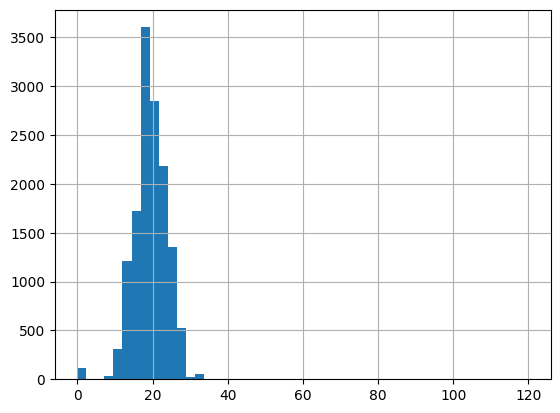

In [10]:
df["mileage"].hist(bins=50);

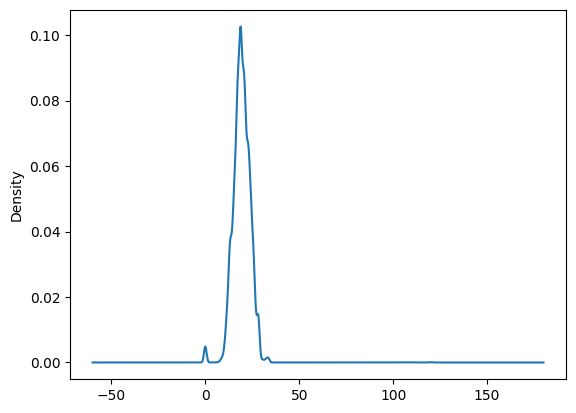

In [11]:
df["mileage"].plot.density();

We observe a skewed plot with right tail to long. An interesting point here would be mileage > 40, because after that it looks like the values mught just be outliers.

Above we saw that there was an unusual peak at 0. Lets investigate further. Looking at points where mileage is less than 5

In [12]:
df[df["mileage"]<=5].mileage.describe()

,mileage
count,119.000000
mean,0.033613
std,0.366679
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,4.000000


Looks like we just have a number of points with mileage 0. That does not make much sense as it cannot be a real value for car mileage. Investigating mileage=0 cases



In [13]:
df.loc[df.mileage == 0].shape[0] / df.shape[0]

0.008437008437008437

In [14]:
df[df["mileage"] == 0.0].shape

(118, 11)

In [15]:
# Which fuel types have mileage = 0? (electric cars may legitimately have no kmpl value)
df[df["mileage"] == 0.0].fuel_type.value_counts()

,count
fuel_type,
Petrol,73
Diesel,40
Electric,5


Thats a very small number of points. We can safely impute, or drop these points later during pre-processing, but only after checking their fuel type below (electric cars may have no kmpl value).

Above we had also noticed that there was a significant point at mileage=40. After this there were only very few points and looked like outliers. Lets check them

In [16]:
df[df["mileage"] > 40].mileage.describe()

,mileage
count,3.000000
mean,116.666667
std,5.773503
min,110.000000
25%,115.000000
50%,120.000000
75%,120.000000
max,120.000000


In [17]:
df[df["mileage"] > 40].fuel_type.value_counts()

,count
fuel_type,
Electric,3


So all vehicles with mileage > 40 are electric vehicles which makes sense.
So they are not incorrect (error) values.
Let us not remove these points for now

Correlations

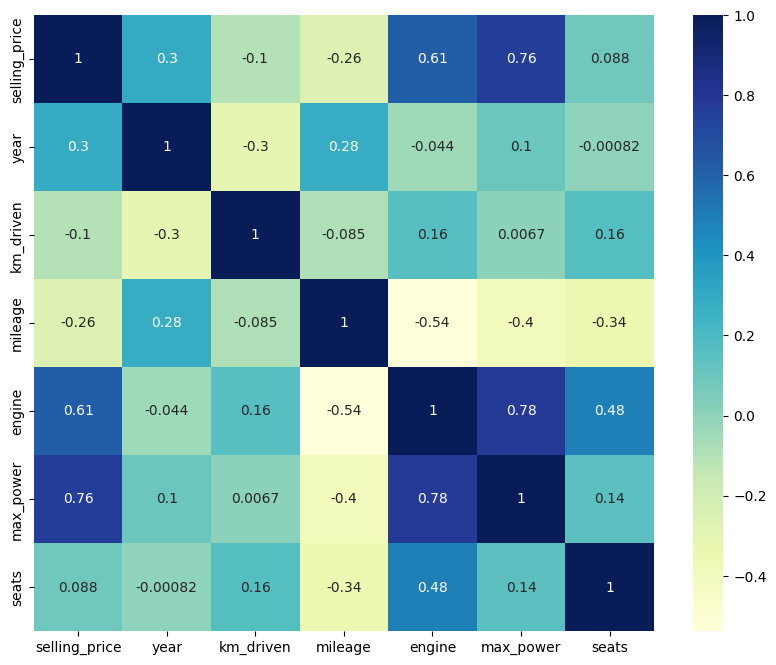

In [18]:
plt.figure(figsize=(10, 8))
ax = sns.heatmap(df.corr(numeric_only=True), cmap="YlGnBu", annot=True)

We see the following correlations:

Engine and max-power.
Max power and selling price Now based on our domain knowledge (about cars) we can digest these correlations. In this case, these correlations seem to make a lot of sense

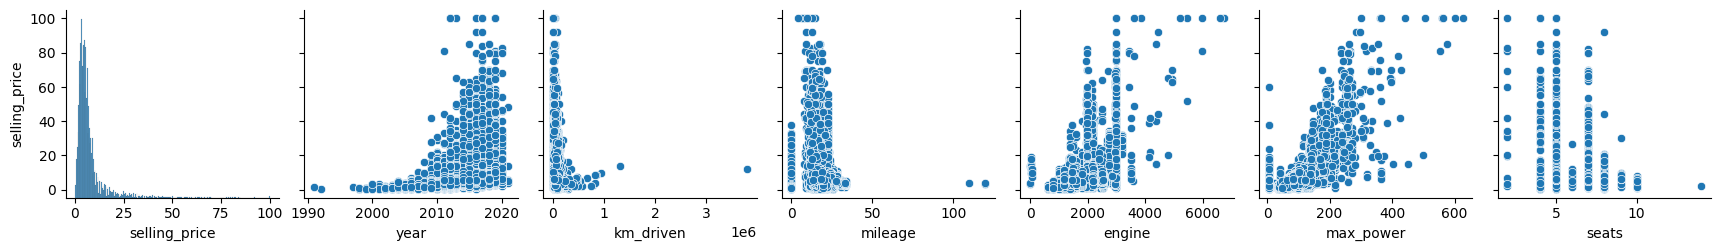

In [19]:
sns.pairplot(df, y_vars=["selling_price"]);

In [20]:
df['seats'].value_counts(normalize=True)

,proportion
seats,
5.0,0.837123
7.0,0.115902
8.0,0.022237
4.0,0.011440
6.0,0.007293
9.0,0.003432
10.0,0.001502
2.0,0.001001
14.0,0.000072


Categorical Variables Treatment

We have noticed that the name contains the informaiton of the brand and the model. Lets extract those and create new features from them. After that we can drop the original column

In [21]:
df["make"] = df.full_name.apply(lambda x : x.split()[0])
df["model"] = df.full_name.apply(lambda x : " ".join(x.split()[1:]))
df = df.drop("full_name", axis=1)
df.head(2)

,selling_price,year,seller_type,km_driven,fuel_type,transmission_type,mileage,engine,max_power,seats,make,model
0,2.85,2007.0,Individual,110000,Petrol,Manual,15.0,1586.0,104.68,5.0,Maruti,SX4 Zxi BSIII
1,4.70,2012.0,Dealer,70000,Diesel,Manual,21.9,1396.0,88.76,5.0,Hyundai,i20 Sportz 1.4 CRDi


Now let us look at some categorical variables one by one

In [22]:
display(df.describe(include="object"))

,seller_type,fuel_type,transmission_type,make,model
count,13986,13986,13986,13986,13986
unique,3,5,2,41,2923
top,Dealer,Petrol,Manual,Maruti,Alto 800 LXI
freq,8393,6870,11251,3979,143


In [23]:
df["fuel_type"].value_counts()

,count
fuel_type,
Petrol,6870
Diesel,6823
CNG,233
LPG,49
Electric,11


In [24]:
df["transmission_type"].value_counts()

,count
transmission_type,
Manual,11251
Automatic,2735


In [25]:
df["seller_type"].value_counts()

,count
seller_type,
Dealer,8393
Individual,5450
Trustmark Dealer,143


Does selling price vary in some of these groups

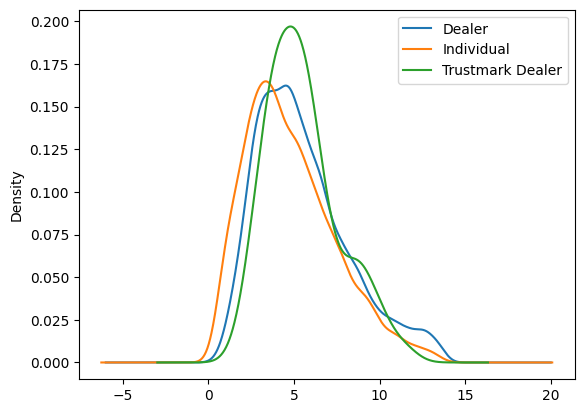

In [26]:
df.loc[df.selling_price<=df.selling_price.quantile(0.9)].groupby('seller_type')['selling_price'].plot.density();
plt.legend();

Looks like for different seller type, the selling price distrubution is not very different. Hence one intuition that can be developed from this plot is that the seller_type variable will not turn out to be very important for the ML model.

Although, seats is numeric, but we will consider it as an ordinal variable and perform similar analysis as we do for other categorical variables.

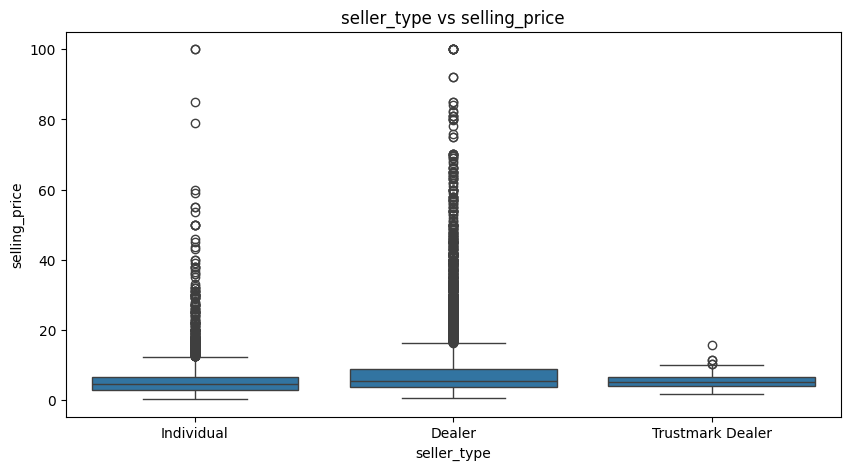

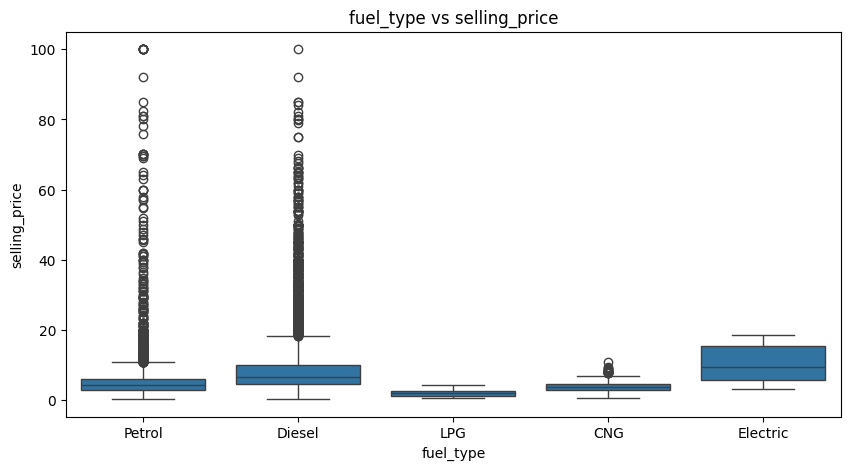

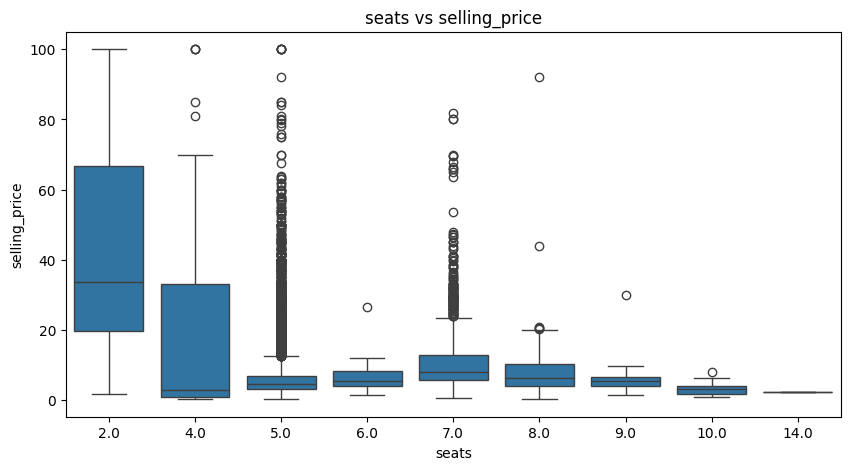

In [27]:
for col in ['seller_type', 'fuel_type', 'seats']:
    plt.figure(figsize=(10,5))
    sns.boxplot(y='selling_price',x=col, data=df)
    plt.title(f'{col} vs selling_price')
    plt.show()

Now we transform the scale of selling-price for better visualisation?

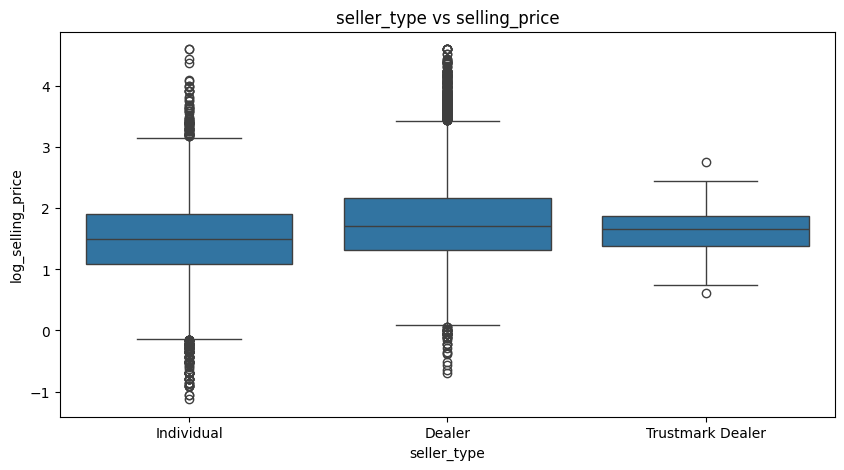

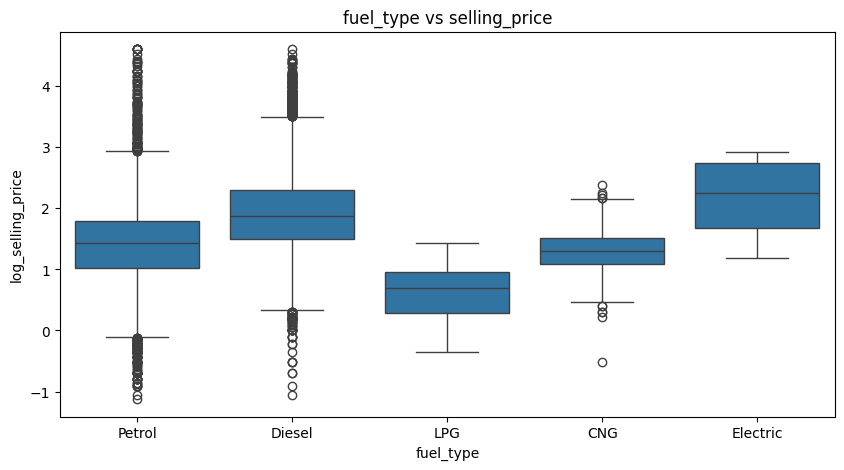

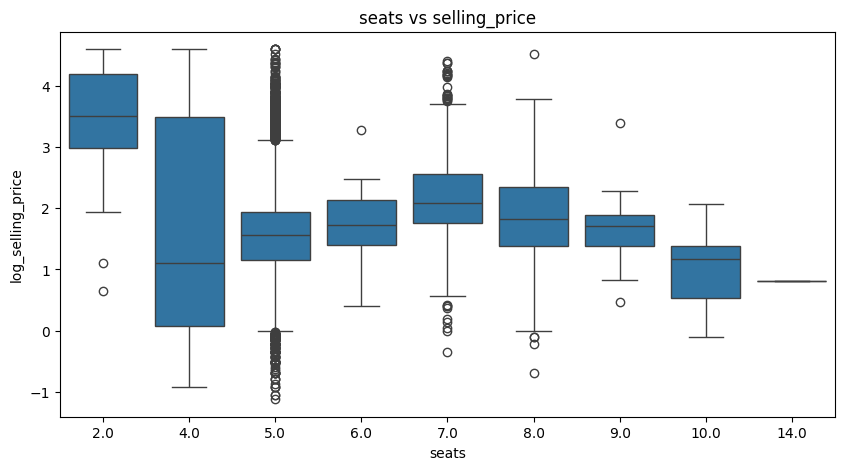

In [28]:
df["log_selling_price"] = np.log(df["selling_price"].values)

for col in ['seller_type', 'fuel_type', 'seats']:
    plt.figure(figsize=(10,5))
    sns.boxplot(y='log_selling_price',x=col, data=df)
    plt.title(f'{col} vs selling_price')
    plt.show()

In [29]:
len(df["make"].unique())

41

There are 41 car brands in the data

Bow lets calculate the item counts for different "make"

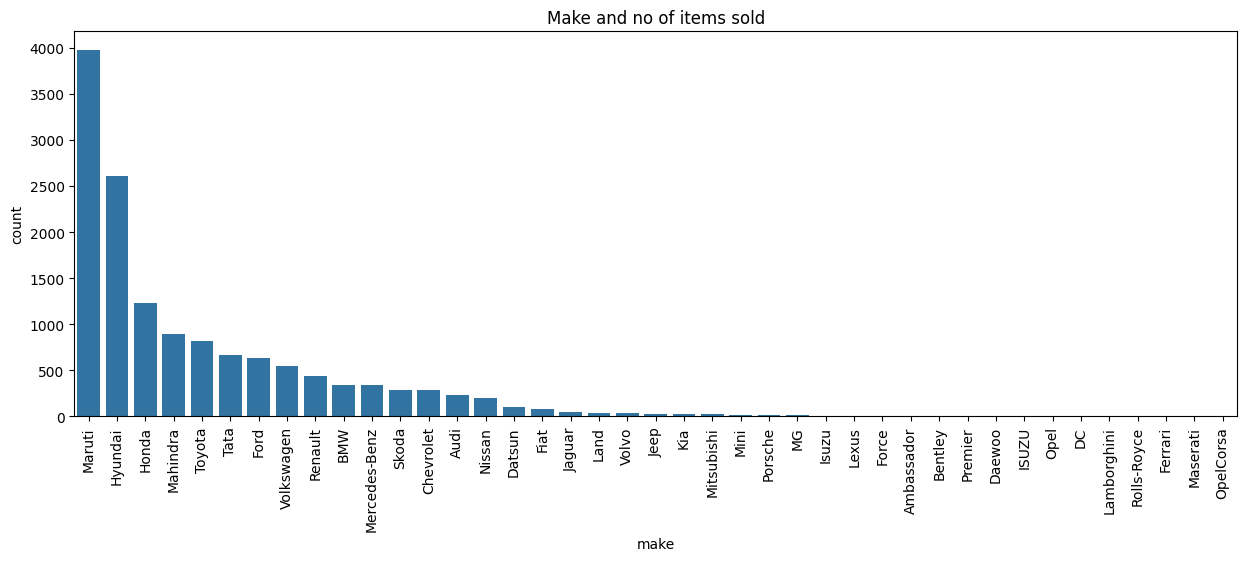

In [30]:
plt.figure(figsize=(15,5))
sns.countplot(x='make', data=df, order = df['make'].value_counts().index)
plt.xticks(rotation=90);
plt.title("Make and no of items sold")
plt.show()

How is "make" related to the selling price?

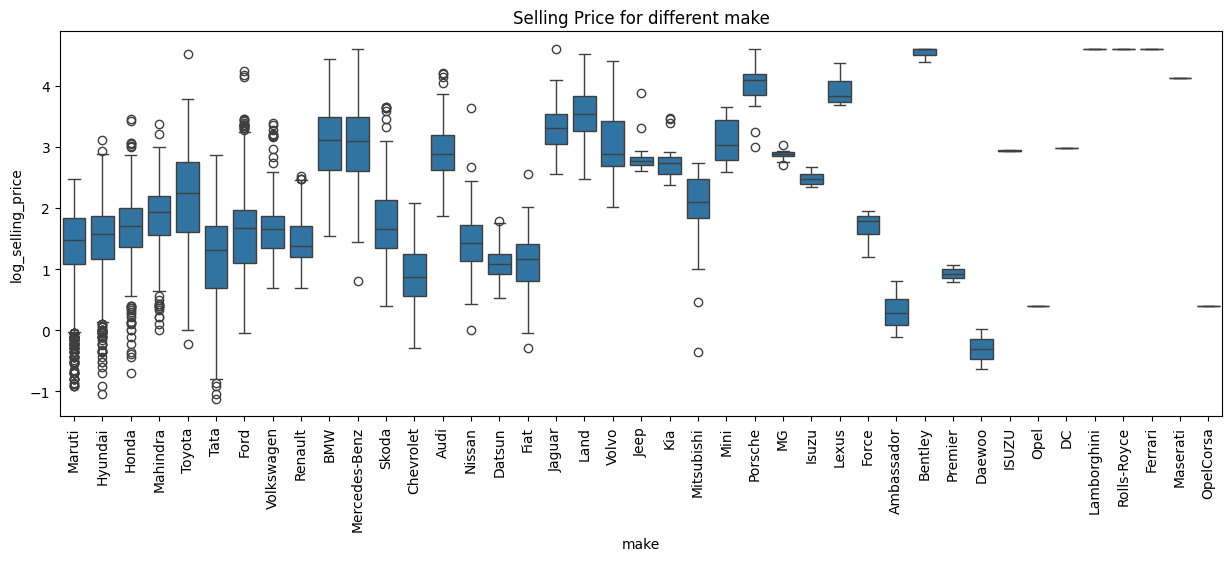

In [31]:
plt.figure(figsize=(15,5))
sns.boxplot(y='log_selling_price',x='make', data=df, order = df['make'].value_counts().index)
plt.xticks(rotation=90);
plt.title("Selling Price for different make")
plt.show()

Lets drop this column for now

In [32]:
df.drop("log_selling_price", axis=1, inplace=True)

Feature Engineering

In [33]:
df.head()

,selling_price,year,seller_type,km_driven,fuel_type,transmission_type,mileage,engine,max_power,seats,make,model
0,2.85,2007.0,Individual,110000,Petrol,Manual,15.00,1586.0,104.68,5.0,Maruti,SX4 Zxi BSIII
1,4.70,2012.0,Dealer,70000,Diesel,Manual,21.90,1396.0,88.76,5.0,Hyundai,i20 Sportz 1.4 CRDi
2,5.25,2015.0,Individual,70000,Diesel,Manual,25.20,1248.0,74.00,5.0,Maruti,Swift VDI BSIV
3,1.25,2005.0,Individual,90000,Petrol,Manual,13.00,1343.0,90.00,5.0,Honda,City 1.3 EXI
4,4.65,2015.0,Dealer,41000,Petrol,Manual,16.47,1198.0,74.00,5.0,Volkswagen,Polo 1.2 MPI Comfortline


Year
Sometimes it is good practice to convert the features into the way we actually understand. This will not necessarily help the model, but helps in us in understanding / interpreting predictions little better

So lets convert year to more readable age

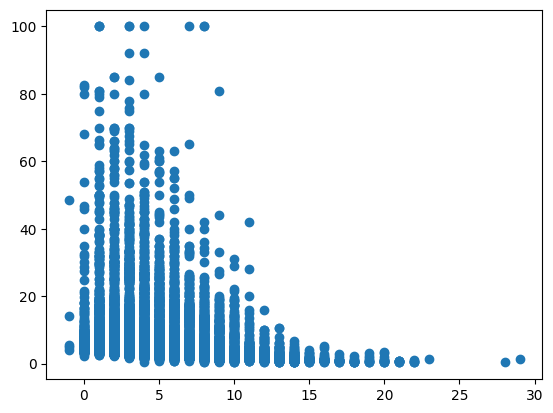

In [34]:
current_year = 2020
df["age"] = current_year - df["year"]
plt.scatter(df["age"], df["selling_price"])  # Higher selling price for newer cars
plt.show()
df = df.drop("year", axis=1)

Categorical Encoding


transmission_type (2 categories)

In [35]:
# Manual = 1, Automatic = 0 (safe to re-run)
if df["transmission_type"].dtype == "object":
    df["transmission_type"] = (
        df["transmission_type"].str.strip().str.lower().eq("manual")
    ).astype(int)
print(df["transmission_type"].value_counts())   # must show both 0 and 1

transmission_type
1    11251
0     2735
Name: count, dtype: int64


fuel_type (5 categores)

In [36]:
df = pd.get_dummies(df, columns=["fuel_type"], prefix="fuel_type", dtype=int)
df.head(2)

,selling_price,seller_type,km_driven,transmission_type,mileage,engine,max_power,seats,make,model,age,fuel_type_CNG,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol
0,2.85,Individual,110000,1,15.0,1586.0,104.68,5.0,Maruti,SX4 Zxi BSIII,13.0,0,0,0,0,1
1,4.70,Dealer,70000,1,21.9,1396.0,88.76,5.0,Hyundai,i20 Sportz 1.4 CRDi,8.0,0,1,0,0,0


seller_type (3 categories)

In [37]:
df = pd.get_dummies(df, columns=["seller_type"], prefix="seller_type", dtype=int)
df.head(2)

,selling_price,km_driven,transmission_type,mileage,engine,max_power,seats,make,model,age,fuel_type_CNG,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer
0,2.85,110000,1,15.0,1586.0,104.68,5.0,Maruti,SX4 Zxi BSIII,13.0,0,0,0,0,1,0,1,0
1,4.70,70000,1,21.9,1396.0,88.76,5.0,Hyundai,i20 Sportz 1.4 CRDi,8.0,0,1,0,0,0,1,0,0


make (too many categoies)

In [38]:
# make: 41 brands -> frequency encoding instead of 41 dummy columns
df["make"] = df["make"].map(df["make"].value_counts(normalize=True))

# model: 2,923 unique values -> drop
df = df.drop("model", axis=1)

Final check and correlation heatmap

selling_price                   float64
km_driven                         int64
transmission_type                 int64
mileage                         float64
engine                          float64
max_power                       float64
seats                           float64
make                            float64
age                             float64
fuel_type_CNG                     int64
fuel_type_Diesel                  int64
fuel_type_Electric                int64
fuel_type_LPG                     int64
fuel_type_Petrol                  int64
seller_type_Dealer                int64
seller_type_Individual            int64
seller_type_Trustmark Dealer      int64
dtype: object


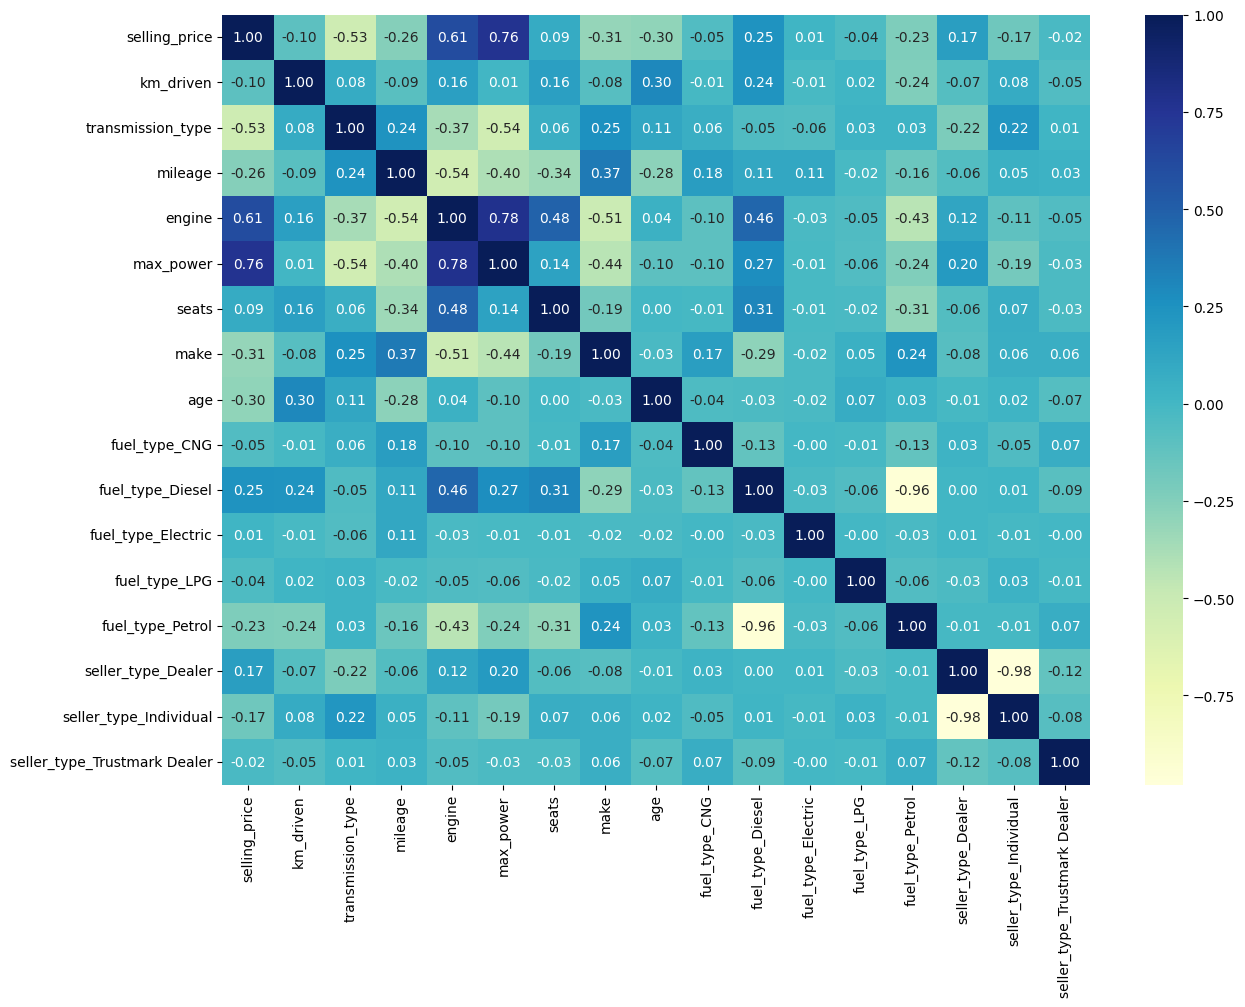

In [39]:
print(df.dtypes)   # everything should be numeric

plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), cmap="YlGnBu", annot=True, fmt=".2f")
plt.show()

Scaling

In [40]:
df.describe()

,selling_price,km_driven,transmission_type,mileage,engine,max_power,seats,make,age,fuel_type_CNG,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer
count,13986.000000,1.398600e+04,13986.000000,13986.000000,13986.000000,13986.000000,13986.000000,13986.000000,13986.000000,13986.000000,13986.000000,13986.000000,13986.000000,13986.000000,13986.000000,13986.000000,13986.000000
mean,7.327126,5.797629e+04,0.804447,19.356221,1473.574905,97.685631,5.313242,0.140482,5.483912,0.016660,0.487845,0.000787,0.003504,0.491205,0.600100,0.389675,0.010225
std,8.310745,5.378180e+04,0.396640,4.638576,518.289204,45.067944,0.831653,0.106131,3.256795,0.127997,0.499870,0.028035,0.059089,0.499941,0.489895,0.487694,0.100602
min,0.325000,1.000000e+02,0.000000,0.000000,0.000000,5.000000,2.000000,0.000072,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.400000,3.100000e+04,1.000000,16.840000,1197.000000,73.900000,5.000000,0.045188,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5.100000,5.120000e+04,1.000000,19.160000,1248.000000,86.700000,5.000000,0.087945,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,7.800000,7.397800e+04,1.000000,22.320000,1582.000000,112.000000,5.000000,0.284499,7.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
max,100.000000,3.800000e+06,1.000000,120.000000,6752.000000,626.000000,14.000000,0.284499,29.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Lets scale this data. We will use MinMaxScaler here

In [41]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

scaler = MinMaxScaler()
scaler.fit(df[['selling_price', 'km_driven', 'mileage']])
scaled_values = scaler.transform(df[['selling_price', 'km_driven', 'mileage']])  # returns numpy.ndarray not df.
scaled_df = pd.DataFrame(scaled_values, columns=['selling_price', 'km_driven', 'mileage'])
scaled_df.head()

,selling_price,km_driven,mileage
0,0.025332,0.028922,0.125000
1,0.043893,0.018395,0.182500
2,0.049411,0.018395,0.210000
3,0.009280,0.023659,0.108333
4,0.043391,0.010763,0.137250


In [42]:
scaled_df.describe()

,selling_price,km_driven,mileage
count,13986.000000,13986.000000,13986.000000
mean,0.070250,0.015231,0.161302
std,0.083378,0.014153,0.038655
min,0.000000,0.000000,0.000000
25%,0.030850,0.008132,0.140333
50%,0.047906,0.013448,0.159667
75%,0.074994,0.019442,0.186000
max,1.000000,1.000000,1.000000


Stichting it all together

In [43]:
CURRENT_YEAR = 2020   # same reference year as the EDA section above

def merge_seats(x):
    if 2 <= x <= 4:
        return '2-4'
    elif x > 5:
        return '>5'
    else:
        return '5'

def preprocess(df):
    # drop invalid mileage = 0 rows, but keep electric cars (mileage in kmpl may not apply)
    df = df.loc[(df.mileage != 0) | (df.fuel_type == 'Electric')].copy()
    outlier_threshold = df.selling_price.quantile(0.95)       # cap price at the 95th percentile
    df.loc[df.selling_price > outlier_threshold, 'selling_price'] = outlier_threshold
    df['age'] = CURRENT_YEAR - df['year']
    df['full_name'] = df['full_name'].str.upper()
    df['seats'] = df['seats'].apply(merge_seats)
    df = df.drop(columns=['year'])                            # keep age, drop year
    return df

def feature_engineering(df):
    df['make'] = df.full_name.apply(lambda x : x.split()[0])
    df['model'] = df.full_name.apply(lambda x : " ".join(x.split()[1:]))
    one_hot_encode_cols = ['seller_type', 'fuel_type', 'transmission_type', 'seats']
    for column in one_hot_encode_cols:
        df = pd.concat([df, pd.get_dummies(df[column], dtype=int).iloc[:, 1:]], axis=1)
    df = df.drop(columns=one_hot_encode_cols + ['full_name'])
    # NOTE: median-price encoding uses the target, so the make/model correlations
    # with price are inflated. Fine for EDA; for modelling, split first and
    # compute these on the training data only.
    df['make'] = df.groupby('make')['selling_price'].transform('median')
    df['model'] = df.groupby('model')['selling_price'].transform('median')
    scaler = MinMaxScaler()
    df = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
    return df

In [44]:
df = pd.read_csv("train-cars24-car-price.csv")
df = preprocess(df)
df = feature_engineering(df)
df.head()

,selling_price,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,0.122128,0.028922,0.125000,0.234893,0.160515,0.482759,0.179031,0.093108,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
1,0.211608,0.018395,0.182500,0.206754,0.134879,0.310345,0.203759,0.200726,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
2,0.238210,0.018395,0.210000,0.184834,0.111111,0.206897,0.179031,0.224184,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
3,0.044740,0.023659,0.108333,0.198904,0.136876,0.551724,0.233432,0.087062,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
4,0.209190,0.010763,0.137250,0.177429,0.111111,0.206897,0.218595,0.229504,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0


In [45]:
df.shape

(13873, 17)

Now checking correlations with all numeric features.

**Note on `model`:** its correlation with price (about 0.97) is an artifact. `model` was encoded with the median selling price, so the target leaks into the feature. Do not read it as a real finding. `make` is affected in the same way, but less.

<Axes: >

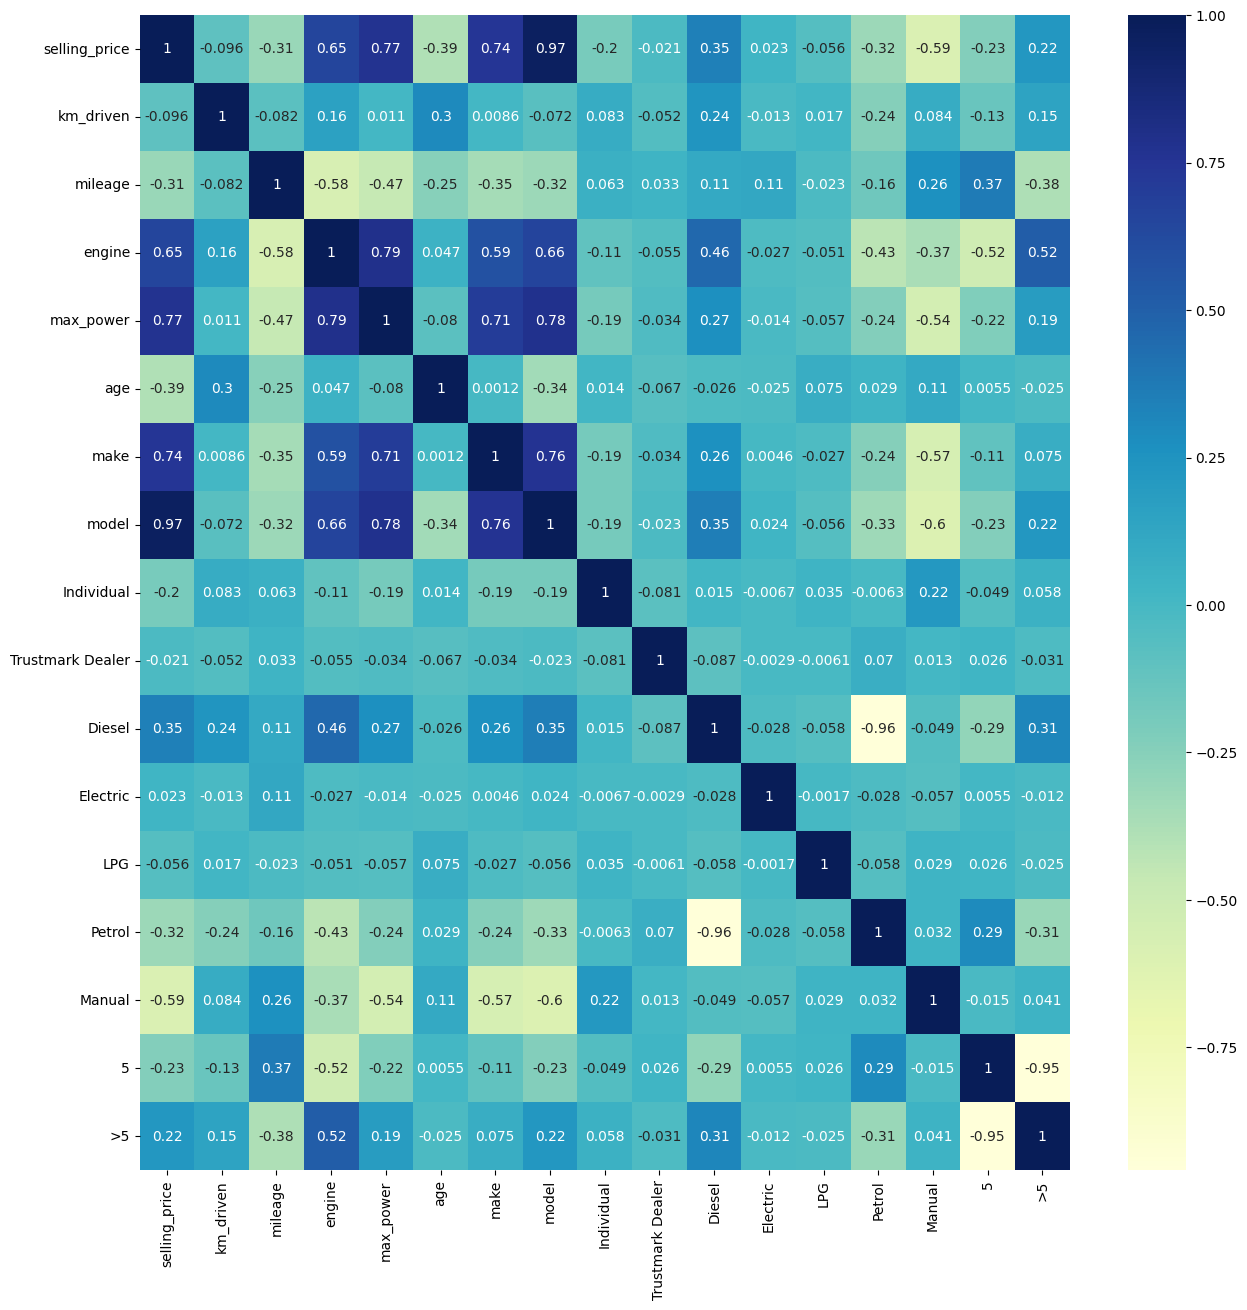

In [46]:
plt.figure(figsize=(15, 15))
sns.heatmap(df.corr(), cmap="YlGnBu", annot=True)

## Conclusions

**Data quality**
- Only 0.06% of listings have a price above 100 lakhs; they were capped.
- 118 rows (0.84%) have mileage = 0. For petrol, diesel, CNG and LPG cars this is not a valid value, so those rows were dropped in the pipeline. Electric cars were kept, since kmpl may not apply to them.
- The 3 listings with mileage above 40 are all electric cars, so they are valid and were kept.
- Price is strongly right-skewed, so `log(selling_price)` is the better target for modelling.

**What drives selling price** (correlation with `selling_price`)
- `max_power` (0.77) and `engine` (0.65) are the strongest genuine drivers. More powerful cars sell for more.
- `make` (0.74) also matters: premium brands sell for more. Part of this is inflated by the encoding used.
- `Manual` transmission (-0.59) is the strongest negative driver and the strongest categorical one. Part of it is indirect: automatics are concentrated in powerful, premium cars.
- `age` (-0.39) and `mileage` (-0.31): older and higher-mileage cars sell for less.
- Diesel cars sell for more (0.35) and petrol cars for less (-0.32).
- `km_driven` (-0.10), seller type and rare fuel types (Electric, LPG) show little linear relationship with price.